In [ ]:
#to fetch ic50 with header  run the bewlow  command in terminal 
#head -n 1 ABL1_P00519_values.csv > ABL1_P00519_IC50_only.csv
#grep "IC50" ABL1_P00519_values.csv >> ABL1_P00519_IC50_only.csv



import pandas as pd
import matplotlib.pyplot as plt   

df= pd.read_csv("dedeuplicated_combined_ic50.csv")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

def load_and_clean(path):
    try:
        df = pd.read_csv(path)
    except Exception as e:
        print(f"ERROR loading data: {e}")
        return None
    if not {'smiles', 'label'}.issubset(df.columns):
        print(f"ERROR: Required columns missing: {df.columns.tolist()}")
        return None
    df = df.dropna(subset=['smiles', 'label'])
    df = df[df['smiles'].str.strip().ne('')].copy()
    df['label'] = pd.to_numeric(df['label'], errors='raise').astype(int)
    print(f"Loaded {len(df)} clean entries; labels: {sorted(df['label'].unique())}")
    return df

def validate_smiles(df, sample_n=500, threshold=0.9):
    smpls = df['smiles'].sample(min(sample_n, len(df)), random_state=42)
    valid = smpls.apply(lambda s: Chem.MolFromSmiles(s) is not None).mean()
    print(f"SMILES valid on sample: {valid:.1%}")
    if valid < threshold:
        df = df[df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)].copy()
        print(f"Filtered invalid SMILES; remaining: {len(df)}")
    return df

def split_and_test(df):
    y = df['label'].values
    min_cls = np.min(np.bincount(y))
    strat = y if min_cls >= 2 else None
    if strat is None:
        print("WARNING: Cannot stratify; some classes with <2 samples")
    X_train, X_test, y_train, y_test = train_test_split(
        df['smiles'].values, y, test_size=0.2, stratify=strat, random_state=42
    )
    ok = sum(AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, 2048) is not None 
             for s in X_train[:5])
    print(f"FP test: {ok}/5 successful")
    return X_train, X_test, y_train, y_test

def gen_fps(smiles, radius=2, nbits=2048):
    fps, idx = [], []
    for i, s in enumerate(smiles):
        m = Chem.MolFromSmiles(s)
        if m:
            bit = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            if bit:
                fps.append(np.array(bit))
                idx.append(i)
    return np.array(fps), idx

from collections import Counter

def apply_smote(X_fp, y, imbalance_thresh=0.5):
    class_counts = Counter(y)
    if len(class_counts) <= 1:
        print("Only one class present, skipping SMOTE")
        return X_fp, y

    majority_class = max(class_counts, key=class_counts.get)
    minority_class = min(class_counts, key=class_counts.get)
    ratio = class_counts[minority_class] / class_counts[majority_class]

    print(f"Class distribution before SMOTE: {dict(class_counts)}")
    
    if ratio < imbalance_thresh:
        print("Applying SMOTE...")
        minority_count = class_counts[minority_class]
        k_neighbors = min(5, max(1, minority_count - 1))  # ensure at least 1
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        return sm.fit_resample(X_fp, y)

    print("SMOTE not needed")
    return X_fp, y


def pipeline(path):
    df = load_and_clean(path)
    if df is None: return
    df = validate_smiles(df)
    X_train, X_test, y_train, y_test = split_and_test(df)
    X_tr_fp, tr_idx = gen_fps(X_train)
    if not len(X_tr_fp):
        print("ERROR: No valid fingerprints generated")
        return
    y_tr = y_train[tr_idx]
    X_train_bal, y_train_bal = apply_smote(X_tr_fp, y_tr)
    print(f"Train size: {len(y_tr)} → {len(y_train_bal)} after SMOTE")
    return {
        'df_clean': df,
        'X_train': X_train_bal, 'y_train': y_train_bal,
        'X_test': gen_fps(X_test)[0], 'y_test': y_test
    }

if __name__ == "__main__":
    print("Running pipeline...")
    res = pipeline("dedeuplicated_combined_ic50.csv")
    if res:
        print("Pipeline completed.")
        print(res['df_clean'][['smiles','label']].head())


Running pipeline...
Loaded 3232 clean entries; labels: [0, 1]
SMILES valid on sample: 100.0%
FP test: 5/5 successful
Class distribution before SMOTE: {1: 1712, 0: 873}
SMOTE not needed
Train size: 2585 → 2585 after SMOTE
Pipeline completed.
                                         smiles  label
0                  Brc1c(Br)c(Br)c2[nH]cnc2c1Br      0
1                  Brc1c(Br)c(Br)c2[nH]nnc2c1Br      0
2  Brc1cc(Br)cc(CNc2nccc(-c3ccc4c(c3)OCO4)n2)c1      1
3    Brc1cc(Br)cc(CNc2nccc(n2)-c2ccc3OCOc3c2)c1      1
4      Brc1ccc(CNc2ccnc(-c3ccc4c(c3)OCO4)n2)cn1      0


In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    precision_score, recall_score,
    confusion_matrix, matthews_corrcoef
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# 1) PREPARE DATA — split into training and hold‑out test set
#    ensures test set is never used during parameter tuning
X_train = res['X_train']
y_train = res['y_train']
X_test = res['X_test']
y_test = res['y_test']
print(f"[DATA] {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")

# 2) DEFINE MODELS AND PARAMETER GRIDS for nested CV
#    each grid will be searched with a 5‑fold inner loop
models = {
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42),
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(probability=True, random_state=42))
    ]),
    "KNN": Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ]),
    "NaiveBayes": GaussianNB(),
    "XGBClassifier": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
}
param_grids = {
    "CatBoost": {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1],
        'iterations': [100, 300]
    },
    "SVM": {
        'svc__C': [0.1, 1, 10],
        'svc__gamma': ['scale', 'auto']
    },
    "KNN": {
        'knn__n_neighbors': [3, 5, 7],
        'knn__weights': ['uniform', 'distance']
    },
    "NaiveBayes": {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    "XGBClassifier": {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 300]
    }
}
print(f"[MODELS] Prepared {len(models)} estimators with parameter grids")

# 3) SET UP outer CV splitter for consistency (not used directly since we have a hold‑out test)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("[CV] Stratified 5‑fold configured for inner GridSearchCV")

def tune_and_evaluate(name, estimator, param_grid):
    """
    Performs:
    - Inner 5‑fold GridSearchCV on X_train/y_train to find best hyperparameters
    - Fits best estimator on full X_train
    - Evaluates on hold‑out X_test/y_test
    - Computes precision, recall (sensitivity), specificity, MCC
    - Saves the best model to disk
    """
    print(f"\n----- {name} Grid Search & Evaluation -----")
    
    # 3a) Inner grid search
    grid = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=outer_cv,
        n_jobs=-1,
        verbose=1
    )
    grid.fit(X_train, y_train)
    print(f"[GRID] Best params for {name}: {grid.best_params_}")
    print(f"[GRID] Best CV F1‑macro: {grid.best_score_:.3f}")
    
    # 3b) Fit best estimator on full training data
    best_model = grid.best_estimator_
    best_model.fit(X_train, y_train)
    print(f"[FIT] Trained {name} on all {X_train.shape[0]} training samples")
    
    # 3c) Predict on hold‑out test set
    y_pred = best_model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred, labels=[0, 1]
    ).ravel()
    
    # 3d) Compute metrics
    precision   = precision_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    mcc         = matthews_corrcoef(y_test, y_pred)
    print(f"[TEST] Precision: {precision:.3f}")
    print(f"[TEST] Sensitivity (Recall): {sensitivity:.3f}")
    print(f"[TEST] Specificity: {specificity:.3f}")
    print(f"[TEST] MCC: {mcc:.3f}")
    
    # 3e) Save the best model
    fname = f"{name.lower()}_best_model.pkl"
    joblib.dump(best_model, fname)
    print(f"[SAVE] {name} model saved to {fname}")
    
    return {
        "Model": name,
        "Best_Params": grid.best_params_,
        "CV_F1_Macro": grid.best_score_,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "MCC": mcc
    }

# 4) RUN tuning & evaluation for all models
results = []
for name, model in models.items():
    grid_results = tune_and_evaluate(name, model, param_grids[name])
    results.append(grid_results)

# 5) SUMMARIZE all results
df_results = pd.DataFrame(results)
print("\n=== All Models Summary ===")
print(df_results.to_string(index=False))


[DATA] 2585 train samples, 647 test samples
[MODELS] Prepared 5 estimators with parameter grids
[CV] Stratified 5‑fold configured for inner GridSearchCV

----- CatBoost Grid Search & Evaluation -----
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[GRID] Best params for CatBoost: {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}
[GRID] Best CV F1‑macro: 0.910
[FIT] Trained CatBoost on all 2585 training samples
[TEST] Precision: 0.931
[TEST] Sensitivity (Recall): 0.972
[TEST] Specificity: 0.858
[TEST] MCC: 0.850
[SAVE] CatBoost model saved to catboost_best_model.pkl

----- SVM Grid Search & Evaluation -----
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[GRID] Best params for SVM: {'svc__C': 10, 'svc__gamma': 'auto'}
[GRID] Best CV F1‑macro: 0.902
[FIT] Trained SVM on all 2585 training samples
[TEST] Precision: 0.941
[TEST] Sensitivity (Recall): 0.965
[TEST] Specificity: 0.881
[TEST] MCC: 0.857
[SAVE] SVM model saved to svm_best_model.pkl

----- KNN Grid Se

/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:13:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:13:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:13:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [19:13:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: 

[GRID] Best params for XGBClassifier: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
[GRID] Best CV F1‑macro: 0.903
[FIT] Trained XGBClassifier on all 2585 training samples
[TEST] Precision: 0.909
[TEST] Sensitivity (Recall): 0.958
[TEST] Specificity: 0.812
[TEST] MCC: 0.793
[SAVE] XGBClassifier model saved to xgbclassifier_best_model.pkl

=== All Models Summary ===
        Model                                                 Best_Params  CV_F1_Macro  Precision  Sensitivity  Specificity      MCC
     CatBoost       {'depth': 8, 'iterations': 300, 'learning_rate': 0.1}     0.909677   0.930804     0.972028     0.857798 0.849921
          SVM                        {'svc__C': 10, 'svc__gamma': 'auto'}     0.901668   0.940909     0.965035     0.880734 0.857032
          KNN         {'knn__n_neighbors': 3, 'knn__weights': 'distance'}     0.891356   0.934389     0.962704     0.866972 0.842903
   NaiveBayes                                    {'var_smoothing': 1e-07}     0.695224

In [25]:
#saving test and train dp
import numpy as np

# Assuming you already have these arrays ready
# X_train, X_test, y_train, y_test

np.savez_compressed(
    'train_test_data.npz',
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)
print("✅ Train/test data saved to train_test_data.npz")


✅ Train/test data saved to train_test_data.npz


In [18]:
# Count how many of each
counts = df['label'].value_counts().sort_index()
print("Inactives (0):", counts.get(0, 0))
print("Actives   (1):", counts.get(1, 0))
print(len(df))

Inactives (0): 1091
Actives   (1): 2141
3232


In [3]:

##evaluation of the model
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef,average_precision_score
)


# ── 1) LOAD OR RECONSTRUCT YOUR TEST SET ────────────────────────────────────────
# Option A: If you previously saved your test split, uncomment:
data = np.load('train_test_data.npz')
X_test, y_test = data['X_test'], data['y_test']
# X = np.concatenate([res['X_train'], res['X_test']])
# y = np.concatenate([res['y_train'], res['y_test']])
# _, X_test, _, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

# 2) Load saved models
model_files = {
    'CatBoost':      'catboost_best_model.pkl',
    'SVM':           'svm_best_model.pkl',
    'KNN':           'knn_best_model.pkl',
    'NaiveBayes':    'naivebayes_best_model.pkl',
    'XGBClassifier': 'xgbclassifier_best_model.pkl'
}
models = {name: joblib.load(path) for name, path in model_files.items()}

# 3) Evaluate each model
print(f"{'Model':<12}  {'Prec':>5}  {'Rec':>5}  {'F1':>5}  {'Spec':>5}  {'MCC':>5}  {'ROC AUC':>7}  {'PR AUC':>7}")
print("-"*70)

for name, model in models.items():
    # 3a) Predictions and decision scores
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:,1]
    else:
        # SVM decision_function → scale to [0,1]
        df = model.decision_function(X_test)
        y_score = (df - df.min()) / (df.max() - df.min())

    # 3b) Compute confusion‐matrix‐based metrics
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
    specificity = tn / (tn + fp)
    mcc         = matthews_corrcoef(y_test, y_pred)
    PR_AUC =  average_precision_score(y_test, y_score)
    
    # 3c) ROC AUC
    roc_auc = roc_auc_score(y_test, y_score)
    
    # 3d) Print row
    print(f"{name:<12}  {precision:5.3f}  {recall:5.3f}  {f1:5.3f}  {specificity:5.3f}  {mcc:5.3f}  {roc_auc:7.3f}  {PR_AUC:7.3f}")


Model          Prec    Rec     F1   Spec    MCC  ROC AUC   PR AUC
----------------------------------------------------------------------
CatBoost      0.931  0.972  0.951  0.858  0.850    0.965    0.974
SVM           0.941  0.965  0.953  0.881  0.857    0.968    0.978
KNN           0.934  0.963  0.948  0.867  0.843    0.942    0.948
NaiveBayes    0.916  0.585  0.714  0.894  0.459    0.851    0.884
XGBClassifier  0.909  0.958  0.933  0.812  0.793    0.961    0.969


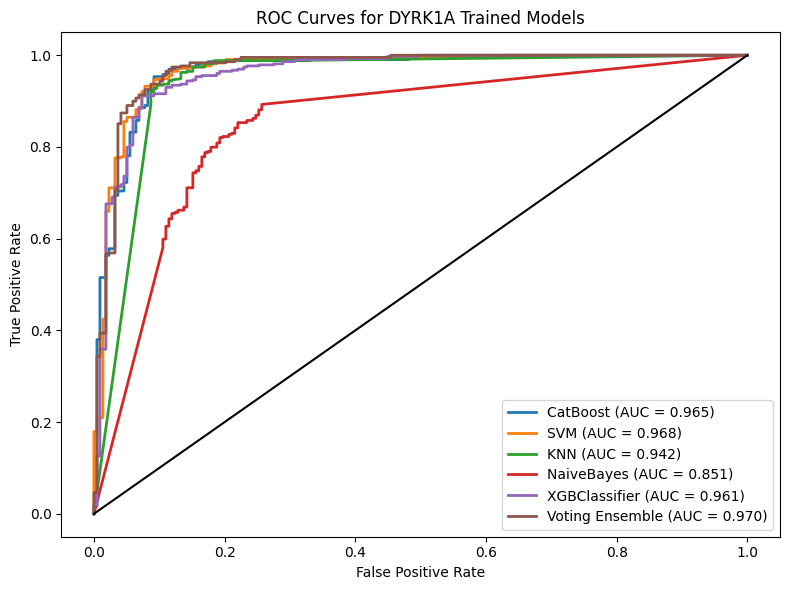

In [ ]:
#ROC Generation
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# LOADING TEST SET ─
data = np.load('train_test_data.npz')
X_test, y_test = data['X_test'], data['y_test']


# ── 2) LOAD YOUR SAVED MODELS ──
model_files = {
    'CatBoost':      'catboost_best_model.pkl',
    'SVM':           'svm_best_model.pkl',
    'KNN':           'knn_best_model.pkl',
    'NaiveBayes':    'naivebayes_best_model.pkl',
    'XGBClassifier': 'xgbclassifier_best_model.pkl',
    'Voting Ensemble': 'cat_xgb_svm_voting.pkl'
}
models = {name: joblib.load(path) for name, path in model_files.items()}

# ── 3) COMPUTE & PLOT ROC FOR EACH MODEL ──
plt.figure(figsize=(8,6))
for name, model in models.items():
    # Get a “score” for each test sample
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        # e.g. SVM without proba
        df = model.decision_function(X_test)
        scores = (df - df.min()) / (df.max() - df.min())  # normalize to [0,1]

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Random chance line
plt.plot([0,1], [0,1], linestyle='-', color='black')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for DYRK1A Trained Models')
plt.legend(loc='lower right')
plt.grid(False)
plt.tight_layout()

plt.savefig('ROC_DYRK1A.png',dpi=300)
plt.show()

In [ ]:
## for voting ensembl
from sklearn.ensemble import VotingClassifier
import joblib
import numpy as np
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix, matthews_corrcoef,
    roc_auc_score, average_precision_score, f1_score
)

# — assume X_train, y_train, X_test, y_test are already prepared —
data = np.load('train_test_data.npz')
X_test, y_test = data['X_test'], data['y_test']
X_train,y_train = data['X_train'], data['y_train']

# 1) Load your tuned base models
cat = joblib.load("catboost_best_model.pkl")
xgb = joblib.load("xgbclassifier_best_model.pkl")
svm = joblib.load("svm_best_model.pkl")

# 2) Build the soft-voting ensemble
voting = VotingClassifier(
    estimators=[
        ('cat', cat),
        ('xgb', xgb),
        ('svm', svm)
    ],
    voting='soft',          
    weights=[2, 1, 2],      
    n_jobs=-1
)

# 3) Fit on your balanced training data
voting.fit(X_train, y_train)

# 4) Predict & evaluate
y_pred  = voting.predict(X_test)
y_proba = voting.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0,1]).ravel()
print("Precision:   ", precision_score(y_test, y_pred))
print("Recall:      ", recall_score(y_test, y_pred))
print("F1:          ", f1_score(y_test, y_pred))
print("Specificity: ", tn / (tn + fp))
print("MCC:         ", matthews_corrcoef(y_test, y_pred))
print("ROC AUC:     ", roc_auc_score(y_test, y_proba))
print("PR AUC:      ", average_precision_score(y_test, y_proba))

# 5) (Optional) Save your ensemble
joblib.dump(voting, "cat_xgb_svm_voting.pkl")


/home/umar/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:41:54] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Precision:    0.9431818181818182
Recall:       0.9673659673659674
F1:           0.9551208285385501
Specificity:  0.8853211009174312
MCC:          0.8640424078779618
ROC AUC:      0.9700017108273988
PR AUC:       0.9771404134989808


['cat_xgb_svm_voting.pkl']

In [12]:
#Library evaluation and screening
import pandas as pd
import numpy as np
import joblib
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.ensemble import VotingClassifier  # if you need to rebuild
from tqdm import tqdm

# 1) Load your trained ensemble
model = joblib.load("cat_xgb_svm_voting.pkl")

# 2) Featurization helper
def smiles_to_fp(smiles_list, radius=2, nbits=2048):
    fps = np.zeros((len(smiles_list), nbits), dtype=np.uint8)
    for i, smi in enumerate(smiles_list):
        m = Chem.MolFromSmiles(smi)
        if m:
            bitvect = AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)
            arr = np.zeros((nbits,), dtype=int)
            DataStructs.ConvertToNumpyArray(bitvect, arr)
            fps[i, :] = arr
    return fps

# 3) Stream in chunks, predict, and write out
input_csv  = "coconut_csv-06-2025.csv"
output_csv = "ensembl_library_with_predictions.csv"
chunksize  = 20_000

reader = pd.read_csv(input_csv, chunksize=chunksize)

# Write header once
first = True
for chunk in tqdm(reader, desc="Chunks"):
    # a) Featurize
    smiles = chunk["canonical_smiles"].fillna("").values
    X_chunk = smiles_to_fp(smiles)

    # b) Predict labels & scores
    y_pred  = model.predict(X_chunk)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_chunk)[:, 1]
    else:
        # fallback to decision_function → sigmoid
        dfun   = model.decision_function(X_chunk)
        y_score = 1 / (1 + np.exp(-dfun))

    # c) Append results to chunk frame
    chunk = chunk.assign(
        pred_label = y_pred,
        pred_score = y_score
    )

    # d) Write (append) to disk
    chunk.to_csv(
        output_csv,
        mode='w' if first else 'a',
        header=first,
        index=False
    )
    first = False

print(f"\n✅ Done! Predictions saved to {output_csv}")


Chunks: 7it [08:15, 70.74s/it]/home/umar/.local/lib/python3.10/site-packages/tqdm/std.py:1181: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  for obj in iterable:
Chunks: 11it [13:04, 71.47s/it][15:59:31] WARNING: not removing hydrogen atom without neighbors
Chunks: 17it [20:17, 72.33s/it][16:06:48] WARNING: not removing hydrogen atom without neighbors
Chunks: 19it [22:41, 72.25s/it]/home/umar/.local/lib/python3.10/site-packages/tqdm/std.py:1181: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  for obj in iterable:
[16:09:08] WARNING: not removing hydrogen atom without neighbors
[16:09:08] WARNING: not removing hydrogen atom without neighbors
[16:09:11] Unusual charge on atom 37 number of radical electrons set to zero
Chunks: 21it [25:03, 71.50s/it][16:11:32] WARNING: not removing hydrogen atom without neighbors
Chunks: 30it [33:43, 55.54s/it]/home/umar/.local/lib/python3.10/si


✅ Done! Predictions saved to ensembl_library_with_predictions.csv


In [15]:
# For active molecule sorting to othr file 

import pandas as pd

# 1) Load the file you just generated
df = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A/ensembl_library_with_predictions.csv")

# 2) Count how many predicted 0’s vs. 1’s
counts = df["pred_label"].value_counts().sort_index()
print("Label counts:\n", counts)

# 3) (Optional) Also show percentages
percent = df["pred_label"].value_counts(normalize=True).sort_index() * 100
print("\nLabel percentages:\n", percent)

# ─────────────────────────────────────────────────────────────────────────────
# 4) Extract only the predicted actives
actives = df.loc[df["pred_label"] == 1, 
                 ["filename","smiles", "pred_score"]]

print(f"\nNumber of actives extracted: {len(actives)}")

# 5) Save them to a new CSV
# actives.to_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A_FDA_Actives.csv", index=False)
print("Saved actives to library_actives_only.csv")


/tmp/ipykernel_715365/2046606404.py:6: DtypeWarning: Columns (38,39,41,43) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/media/umar/New Volume/Shareable folders/Data_TDC/data_IC50_chemberta/ML_MT/DYRK1A/ensembl_library_with_predictions.csv")


Label counts:
 pred_label
0    557075
1    138044
Name: count, dtype: int64

Label percentages:
 pred_label
0    80.140954
1    19.859046
Name: proportion, dtype: float64


KeyError: "['filename', 'smiles'] not in index"